<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/08_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 4 — SHAP (SHapley Additive exPlanations)

**Objective:** SHAP assigns a contribution score to each pixel/region of the input
image, quantifying how much each part pushed the prediction toward or away from
the pneumonia class. Unlike Grad-CAM which shows where the model looked, SHAP
tells us how much each region influenced the final decision — positive values
push toward pneumonia, negative values push toward normal.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## 01. Rebuild Model & Load Checkpoint

The trained ResNet-50 checkpoint is reloaded here — identical to 07.
SHAP requires the model in eval() mode with no gradient tracking during
the explanation phase. The same custom fully connected head and sigmoid
output are used.

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'opencv-python-headless'], check=True)
    import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

print(f"Compute device : {device}")
print("Checkpoint loaded — model in eval mode.")

Mounted at /content/drive
Compute device : cuda
Checkpoint loaded — model in eval mode.


## 02. Install & Import SHAP

SHAP is not pre-installed in Colab. We install it once, then import the
PartitionExplainer — a model-agnostic explainer that treats the model as
a black box and uses a blur masker as the baseline. This approach avoids
the inplace operation conflicts that GradientExplainer and DeepExplainer
encounter with ResNet's residual connections.

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'shap', '-q'], check=True)
import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


## 03. Preprocessing & Background Dataset

The same normalisation parameters from training are applied. A background
dataset of 50 random training images is built for reference — note that
PartitionExplainer uses a blur masker as its baseline rather than the
background tensor directly. The background tensor is retained here for
completeness and potential use with other explainers.

In [3]:
import os
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"emanaymanabukhousa","key":"{userdata.get("KAGGLE_KEY")}"}}\n')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/images --unzip

print("Done.")
!ls /content/images/chest_xray/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:10<00:00, 18.9MB/s]

Done.
chest_xray  __MACOSX  test  train  val


## 04. Build Background Dataset

50 random images from the training set are selected as the SHAP background.
These are preprocessed using the same transforms as training and stacked
into a single tensor. This background represents the baseline the model
is compared against when computing SHAP values.

In [4]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5330, 0.5330, 0.5330],
                         std=[0.0349, 0.0349, 0.0349]),
])

def load_image(path):
    img_pil = Image.open(path).convert('RGB').resize((224, 224))
    tensor = val_transforms(img_pil).unsqueeze(0)
    return img_pil, tensor

# Build background from 50 random training images
train_dir = '/content/images/chest_xray/train'
all_train_files = []
for label in ['NORMAL', 'PNEUMONIA']:
    folder = os.path.join(train_dir, label)
    for f in os.listdir(folder):
        if f.endswith(('.jpeg', '.jpg', '.png')):
            all_train_files.append(os.path.join(folder, f))

np.random.seed(42)
background_paths = np.random.choice(all_train_files, 50, replace=False)
background_tensors = torch.cat([
    val_transforms(Image.open(p).convert('RGB').resize((224, 224))).unsqueeze(0)
    for p in background_paths
], dim=0).to(device)

print(f"Background tensor shape: {background_tensors.shape}")
print("Background dataset ready.")

Background tensor shape: torch.Size([50, 3, 224, 224])
Background dataset ready.


## 05. Initialise SHAP PartitionExplainer

The GradientExplainer is initialised with the model and the background dataset.
We wrap the model in a helper that extracts the sigmoid probability — since our
model outputs a single logit, we apply sigmoid before passing to SHAP so the
explanation is relative to the final probability, not the raw logit.

In [14]:
def remove_inplace(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False

remove_inplace(model)

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.sigmoid(self.model(x)).squeeze(-1)

wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

# Use blur masker instead — avoids inpaint format issues
masker = shap.maskers.Image("blur(128,128)", (224, 224, 3))

def predict(imgs):
    imgs = torch.tensor(imgs, dtype=torch.float32).permute(0,3,1,2).to(device)
    with torch.no_grad():
        return wrapped_model(imgs).cpu().numpy()

explainer = shap.Explainer(predict, masker)
print("PartitionExplainer with blur masker initialised.")

PartitionExplainer with blur masker initialised.


## 06. Compute SHAP Values

SHAP values are computed for one NORMAL and one PNEUMONIA image from the
test set. Each pixel receives a SHAP value — positive values (red) pushed
the prediction toward pneumonia, negative values (blue) pushed it toward
normal. The absolute magnitude indicates

In [18]:
test_dir = '/content/images/chest_xray/test'

normal_img_path = os.path.join(
    test_dir, 'NORMAL',
    os.listdir(os.path.join(test_dir, 'NORMAL'))[0]
)
pneumo_img_path = os.path.join(
    test_dir, 'PNEUMONIA',
    os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[0]
)

normal_pil, normal_tensor = load_image(normal_img_path)
pneumo_pil, pneumo_tensor = load_image(pneumo_img_path)


# Images are scaled to [0,1] for SHAP. Normalisation is applied inside
# predict() to match training input distribution.

# Apply same normalisation as training for model input consistency
normal_img_np = np.array(normal_pil).astype(np.float32) / 255.0
pneumo_img_np = np.array(pneumo_pil).astype(np.float32) / 255.0

normal_shap_vals = explainer(normal_img_np[np.newaxis, ...],
                              max_evals=500, batch_size=50)
pneumo_shap_vals = explainer(pneumo_img_np[np.newaxis, ...],
                              max_evals=500, batch_size=50)

print("SHAP values computed.")
print(f"Normal SHAP shape : {normal_shap_vals.shape}")
print(f"Pneumo SHAP shape : {pneumo_shap_vals.shape}")

SHAP values computed.
Normal SHAP shape : (1, 224, 224, 3)
Pneumo SHAP shape : (1, 224, 224, 3)


## 07. Visualise SHAP Values

SHAP values are averaged across the 3 colour channels to produce a single
heatmap per image. Red regions pushed the prediction toward pneumonia,
blue regions pushed it toward normal. The original X-ray is shown alongside
the SHAP heatmap and an overlay for direct comparison. Colour scale is symmetric around zero to preserve positive/negative contribution balance.

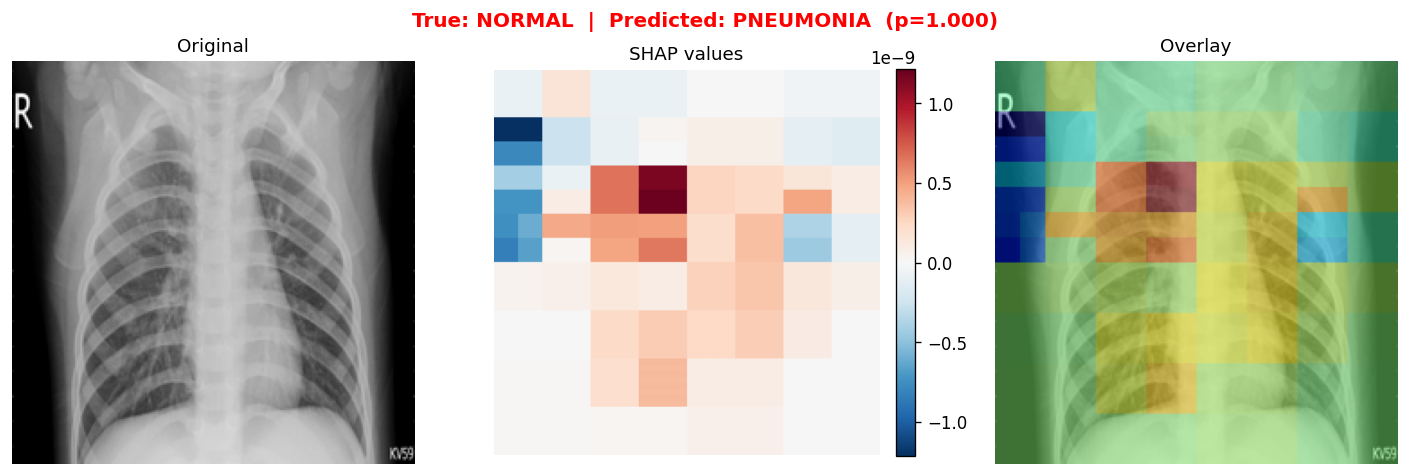

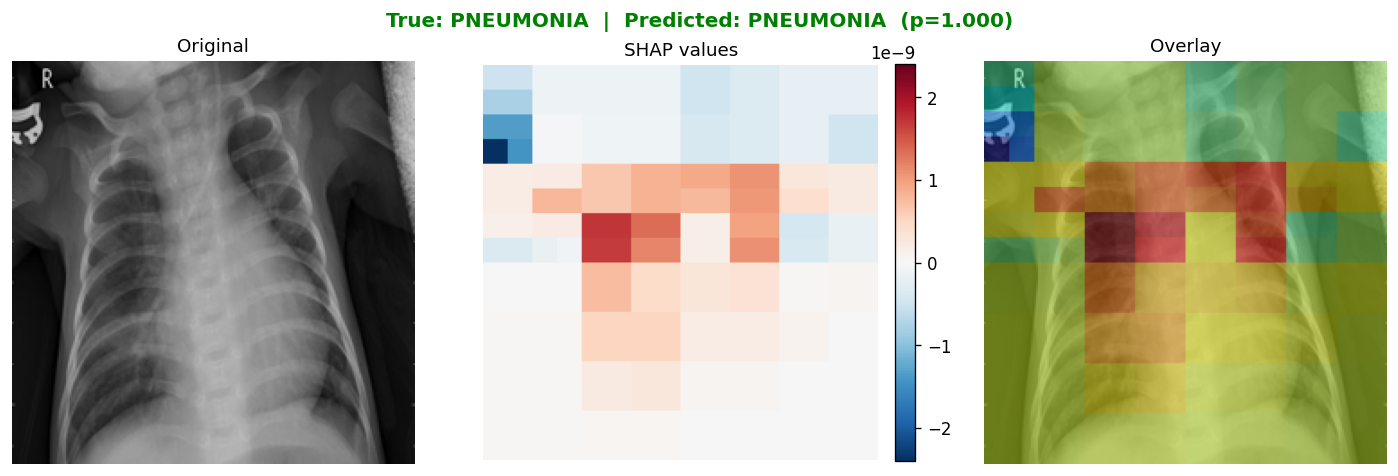

In [16]:
def plot_shap_row(img_pil, shap_vals, true_label):
    # Average SHAP across colour channels
    shap_map = shap_vals.values[0].mean(axis=-1)  # (224, 224)

    with torch.no_grad():
        tensor = val_transforms(img_pil).unsqueeze(0).to(device)
        prob = wrapped_model(tensor).item()

    pred_label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    colour = 'green' if pred_label == true_label else 'red'

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_pil, cmap='gray')
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    abs_max = np.abs(shap_map).max()
    hm = axes[1].imshow(shap_map, cmap='RdBu_r',
                        vmin=-abs_max, vmax=abs_max)
    axes[1].set_title('SHAP values', fontsize=11)
    axes[1].axis('off')
    plt.colorbar(hm, ax=axes[1], fraction=0.046, pad=0.04)

    shap_norm = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min())
    shap_uint8 = np.uint8(255 * shap_norm)
    heatmap = cv2.applyColorMap(cv2.resize(shap_uint8, (224, 224)), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np = np.array(img_pil)
    overlay = np.uint8(0.45 * heatmap_rgb + 0.55 * img_np)

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay', fontsize=11)
    axes[2].axis('off')

    fig.suptitle(
        f'True: {true_label}  |  Predicted: {pred_label}  (p={prob:.3f})',
        fontsize=12, fontweight='bold', color=colour
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/shap_{true_label.lower()}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

plot_shap_row(normal_pil, normal_shap_vals, 'NORMAL')
plot_shap_row(pneumo_pil, pneumo_shap_vals, 'PNEUMONIA')

## 08. SHAP on False Negatives (Missed Pneumonia)

The same 3 false negatives identified in Day 7 are analysed with SHAP.
This shows not just where the model looked, but how much each region
contributed to the wrong prediction — complementing the Grad-CAM analysis
from Day 7.

False negatives found: 3


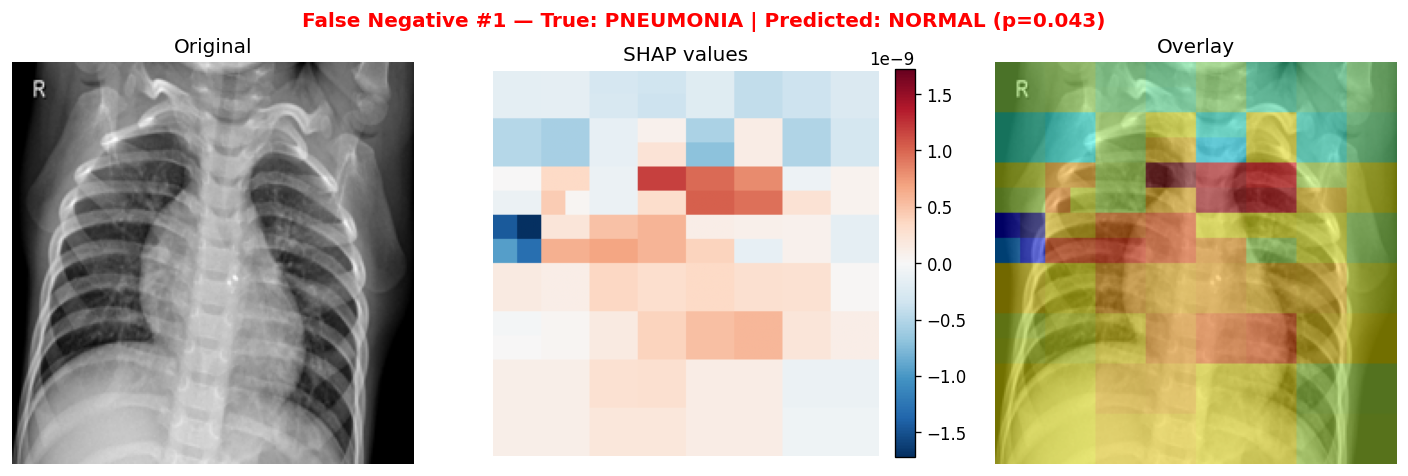

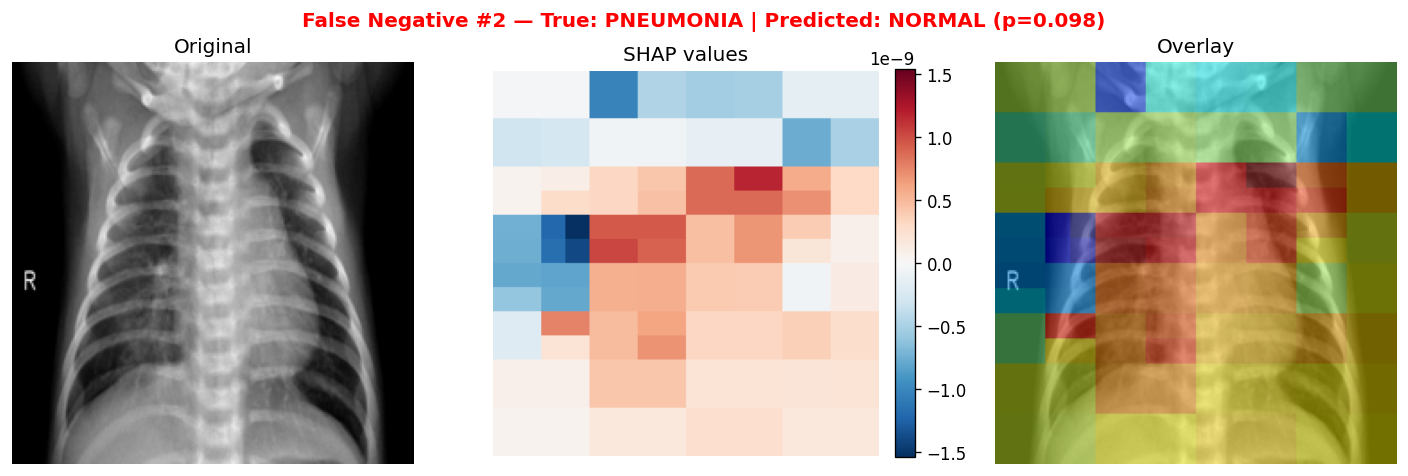

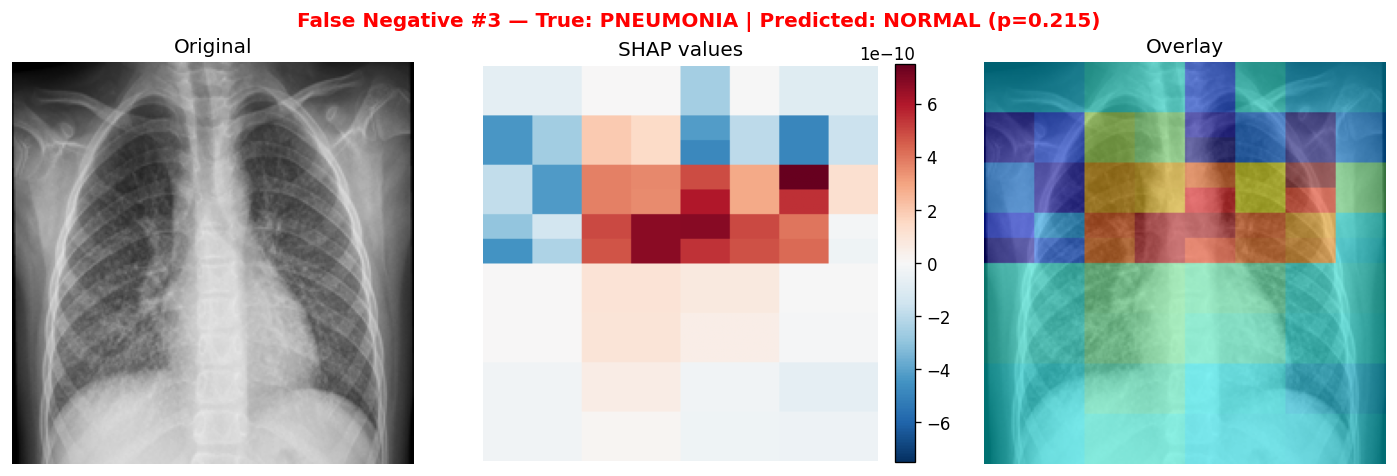

In [17]:
import pandas as pd

def build_dataframe(data_dir, splits):
    records = []
    for split in splits:
        for label, idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith(('.jpeg', '.jpg', '.png')):
                    records.append({
                        'filepath': os.path.join(folder, fname),
                        'label': idx
                    })
    return pd.DataFrame(records)

test_df = build_dataframe('/content/images/chest_xray', ['test'])

all_probs, all_labels, all_paths = [], [], []
with torch.no_grad():
    for _, row in test_df.iterrows():
        img_pil = Image.open(row['filepath']).convert('RGB')
        tensor = val_transforms(img_pil).unsqueeze(0).to(device)
        prob = wrapped_model(tensor).item()
        all_probs.append(prob)
        all_labels.append(row['label'])
        all_paths.append(row['filepath'])

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

fn_mask  = (all_labels == 1) & (all_probs < 0.5)
fn_paths = [p for p, m in zip(all_paths, fn_mask) if m]
fn_probs = all_probs[fn_mask]

print(f"False negatives found: {len(fn_paths)}")

for i, (path, prob) in enumerate(zip(fn_paths, fn_probs)):
    img_pil, _ = load_image(path)
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    shap_vals = explainer(img_np[np.newaxis, ...], max_evals=500, batch_size=50)
    shap_map = shap_vals.values[0].mean(axis=-1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_pil, cmap='gray'); axes[0].axis('off')
    axes[0].set_title('Original')
    abs_max = np.abs(shap_map).max()
    hm = axes[1].imshow(shap_map, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[1].axis('off'); axes[1].set_title('SHAP values')
    plt.colorbar(hm, ax=axes[1], fraction=0.046, pad=0.04)
    shap_norm = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min())
    heatmap = cv2.applyColorMap(np.uint8(255 * shap_norm), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.45 * heatmap_rgb + 0.55 * np.array(img_pil))
    axes[2].imshow(overlay); axes[2].axis('off'); axes[2].set_title('Overlay')
    fig.suptitle(
        f'False Negative #{i+1} — True: PNEUMONIA | Predicted: NORMAL (p={prob:.3f})',
        fontsize=12, fontweight='bold', color='red'
    )
    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/medical-xai/shap_fn_{i+1}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

Clinical Interpretation — SHAP

SHAP values quantify the contribution of each image region to the final
prediction. Red regions pushed the model toward pneumonia, blue regions
pushed it toward normal.

In the false negative cases, SHAP reveals that the model detected some
pneumonia-relevant signal in the upper lung fields (red) but was
simultaneously suppressed by strong negative contributions (blue) in
other regions — resulting in a net prediction below the 0.5 threshold.
This describes a decision boundary conflict inside the image and explains
mechanistically why these cases were missed.

Unlike Grad-CAM which shows where the model attended, SHAP shows the
direction and magnitude of each region's influence — making it a more
complete explanation tool for clinical audit.

**Limitations:** Channel-specific SHAP information is lost by averaging
across RGB channels — acceptable for greyscale X-rays but worth noting.
max_evals=500 is a speed/accuracy trade-off — sufficient for demonstration
but not scalable to large datasets. PartitionExplainer uses a blur masker
baseline rather than a dataset-derived baseline, which means explanations
are relative to a blurred version of the image rather than an average
training image.